In [1]:
from pathlib import Path

BASE_DIR = Path("e5_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e5_artifacts/logs
/content/e5_artifacts/tables
/content/e5_artifacts/figures
/content/e5_artifacts/reports


In [2]:
import pandas as pd

TRAIN_PATH = "train_final.csv"
TEST_PATH = "test_final.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train_df shape: (7957, 3)
test_df shape: (2211, 3)


,text,label,id
0,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501
1,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352
2,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569
3,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912
4,сижу в такси рядом ползает паук няшка,positive,1276191130535821315


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [3]:
SEED = 42

X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_test: (2211,)
y_test: (2211,)


In [4]:
import json

E5_CONFIG = {
    "experiment": "E5 classical ensemble study",
    "dataset": "RuSentiTweet",
    "train_file": TRAIN_PATH,
    "test_file": TEST_PATH,
    "seed": SEED,
    "representation": {
        "type": "TfidfVectorizer",
        "lowercase": True,
        "analyzer": "char_wb",
        "ngram_range": (3, 5),
        "min_df": 2,
        "max_df": 0.95
    },
    "base_models": {
        "SGDClassifier hinge default": {
            "class_weight": None,
            "loss": "hinge"
        },
        "RidgeClassifier balanced": {
            "class_weight": "balanced"
        },
        "Linear SVM balanced": {
            "class_weight": "balanced"
        }
    },
    "ensemble_methods": [
        "hard_voting",
        "soft_voting_equal",
        "soft_voting_weighted"
    ],
    "weighted_soft_weights_raw": {
        "SGDClassifier hinge default": 0.6741,
        "RidgeClassifier balanced": 0.6686,
        "Linear SVM balanced": 0.6678
    }
}

with open(LOG_DIR / "e5_config.json", "w", encoding="utf-8") as f:
    json.dump(E5_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e5_config.json")

Saved: e5_artifacts/logs/e5_config.json


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

print("X_train_char shape:", X_train_char.shape)
print("X_test_char shape:", X_test_char.shape)

X_train_char shape: (7957, 78069)
X_test_char shape: (2211, 78069)


In [6]:
import time
import numpy as np

from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [7]:
sgd_base = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

ridge_base = RidgeClassifier(
    class_weight="balanced"
)

svm_base = LinearSVC(
    class_weight="balanced",
    random_state=SEED
)

In [8]:
def evaluate_predictions(
    model_name,
    ensemble_type,
    y_true,
    y_pred,
    train_time_sec,
    report_filename
):
    acc = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro")

    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)

    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report_text)

    result = {
        "model": model_name,
        "ensemble_type": ensemble_type,
        "representation": "char TF-IDF (3,5)",
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "train_time_sec": round(train_time_sec, 4),
        "seed": SEED
    }

    return result, report_text

In [9]:
start_time_hard = time.time()

sgd_hard = clone(sgd_base)
ridge_hard = clone(ridge_base)
svm_hard = clone(svm_base)

sgd_hard.fit(X_train_char, y_train)
ridge_hard.fit(X_train_char, y_train)
svm_hard.fit(X_train_char, y_train)

train_time_hard = time.time() - start_time_hard

print("Hard ensemble fit time:", round(train_time_hard, 4))

Hard ensemble fit time: 3.4531


In [10]:
pred_sgd_hard = sgd_hard.predict(X_test_char)
pred_ridge_hard = ridge_hard.predict(X_test_char)
pred_svm_hard = svm_hard.predict(X_test_char)

hard_vote_df = pd.DataFrame({
    "sgd": pred_sgd_hard,
    "ridge": pred_ridge_hard,
    "svm": pred_svm_hard
})

hard_vote_df.head()

,sgd,ridge,svm
0,neutral,neutral,neutral
1,neutral,neutral,neutral
2,neutral,neutral,neutral
3,neutral,neutral,neutral
4,positive,positive,positive


In [11]:
y_pred_hard = hard_vote_df.mode(axis=1)[0].values
print(y_pred_hard[:10])

['neutral' 'neutral' 'neutral' 'neutral' 'positive' 'neutral' 'negative'
 'positive' 'neutral' 'neutral']


In [12]:
e5_results = []

res_hard, rep_hard = evaluate_predictions(
    model_name="Classical ensemble hard voting",
    ensemble_type="hard_voting",
    y_true=y_test,
    y_pred=y_pred_hard,
    train_time_sec=train_time_hard,
    report_filename="classification_report_hard_voting.txt"
)

e5_results.append(res_hard)

print(res_hard)
print(rep_hard)

{'model': 'Classical ensemble hard voting', 'ensemble_type': 'hard_voting', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6716, 'precision_weighted': 0.669, 'recall_weighted': 0.6716, 'weighted_f1': 0.6686, 'macro_f1': 0.6486, 'train_time_sec': 3.4531, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6388    0.6136    0.6260       660
     neutral     0.6991    0.7659    0.7310      1068
    positive     0.6437    0.5424    0.5888       483

    accuracy                         0.6716      2211
   macro avg     0.6606    0.6407    0.6486      2211
weighted avg     0.6690    0.6716    0.6686      2211



In [13]:
sgd_cal = CalibratedClassifierCV(
    estimator=clone(sgd_base),
    method="sigmoid",
    cv=3
)

ridge_cal = CalibratedClassifierCV(
    estimator=clone(ridge_base),
    method="sigmoid",
    cv=3
)

svm_cal = CalibratedClassifierCV(
    estimator=clone(svm_base),
    method="sigmoid",
    cv=3
)

In [14]:
start_time_soft = time.time()

sgd_cal.fit(X_train_char, y_train)
ridge_cal.fit(X_train_char, y_train)
svm_cal.fit(X_train_char, y_train)

train_time_soft = time.time() - start_time_soft

print("Soft ensemble fit time:", round(train_time_soft, 4))

Soft ensemble fit time: 7.4607


In [15]:
proba_sgd = sgd_cal.predict_proba(X_test_char)
proba_ridge = ridge_cal.predict_proba(X_test_char)
proba_svm = svm_cal.predict_proba(X_test_char)

print(proba_sgd.shape, proba_ridge.shape, proba_svm.shape)

(2211, 3) (2211, 3) (2211, 3)


In [16]:
print("SGD classes:", sgd_cal.classes_)
print("Ridge classes:", ridge_cal.classes_)
print("SVM classes:", svm_cal.classes_)

SGD classes: ['negative' 'neutral' 'positive']
Ridge classes: ['negative' 'neutral' 'positive']
SVM classes: ['negative' 'neutral' 'positive']


In [17]:
avg_proba_equal = (proba_sgd + proba_ridge + proba_svm) / 3
classes_order = sgd_cal.classes_

y_pred_soft_equal = classes_order[np.argmax(avg_proba_equal, axis=1)]

res_soft_equal, rep_soft_equal = evaluate_predictions(
    model_name="Classical ensemble soft voting equal",
    ensemble_type="soft_voting_equal",
    y_true=y_test,
    y_pred=y_pred_soft_equal,
    train_time_sec=train_time_soft,
    report_filename="classification_report_soft_voting_equal.txt"
)

e5_results.append(res_soft_equal)

print(res_soft_equal)
print(rep_soft_equal)

{'model': 'Classical ensemble soft voting equal', 'ensemble_type': 'soft_voting_equal', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6771, 'precision_weighted': 0.6805, 'recall_weighted': 0.6771, 'weighted_f1': 0.668, 'macro_f1': 0.644, 'train_time_sec': 7.4607, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6781    0.5712    0.6201       660
     neutral     0.6687    0.8333    0.7420      1068
    positive     0.7099    0.4762    0.5700       483

    accuracy                         0.6771      2211
   macro avg     0.6855    0.6269    0.6440      2211
weighted avg     0.6805    0.6771    0.6680      2211



In [18]:
raw_weights = np.array([0.6741, 0.6686, 0.6678], dtype=float)
weights = raw_weights / raw_weights.sum()

print("Normalized weights:", weights)

Normalized weights: [0.33528973 0.33255409 0.33215618]


In [19]:
avg_proba_weighted = (
    weights[0] * proba_sgd +
    weights[1] * proba_ridge +
    weights[2] * proba_svm
)

y_pred_soft_weighted = classes_order[np.argmax(avg_proba_weighted, axis=1)]

res_soft_weighted, rep_soft_weighted = evaluate_predictions(
    model_name="Classical ensemble soft voting weighted",
    ensemble_type="soft_voting_weighted",
    y_true=y_test,
    y_pred=y_pred_soft_weighted,
    train_time_sec=train_time_soft,
    report_filename="classification_report_soft_voting_weighted.txt"
)

e5_results.append(res_soft_weighted)

print(res_soft_weighted)
print(rep_soft_weighted)

{'model': 'Classical ensemble soft voting weighted', 'ensemble_type': 'soft_voting_weighted', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6771, 'precision_weighted': 0.6805, 'recall_weighted': 0.6771, 'weighted_f1': 0.668, 'macro_f1': 0.644, 'train_time_sec': 7.4607, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6781    0.5712    0.6201       660
     neutral     0.6687    0.8333    0.7420      1068
    positive     0.7099    0.4762    0.5700       483

    accuracy                         0.6771      2211
   macro avg     0.6855    0.6269    0.6440      2211
weighted avg     0.6805    0.6771    0.6680      2211



In [20]:
e5_results_df = pd.DataFrame(e5_results)
e5_results_df = e5_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e5_results_df)

,model,ensemble_type,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed
0,Classical ensemble hard voting,hard_voting,"char TF-IDF (3,5)",0.6716,0.6690,0.6716,0.6686,0.6486,3.4531,42
1,Classical ensemble soft voting equal,soft_voting_equal,"char TF-IDF (3,5)",0.6771,0.6805,0.6771,0.6680,0.6440,7.4607,42
2,Classical ensemble soft voting weighted,soft_voting_weighted,"char TF-IDF (3,5)",0.6771,0.6805,0.6771,0.6680,0.6440,7.4607,42


In [21]:
e5_results_df.to_csv(TABLE_DIR / "e5_ensemble_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e5_ensemble_results.csv")

Saved: e5_artifacts/tables/e5_ensemble_results.csv


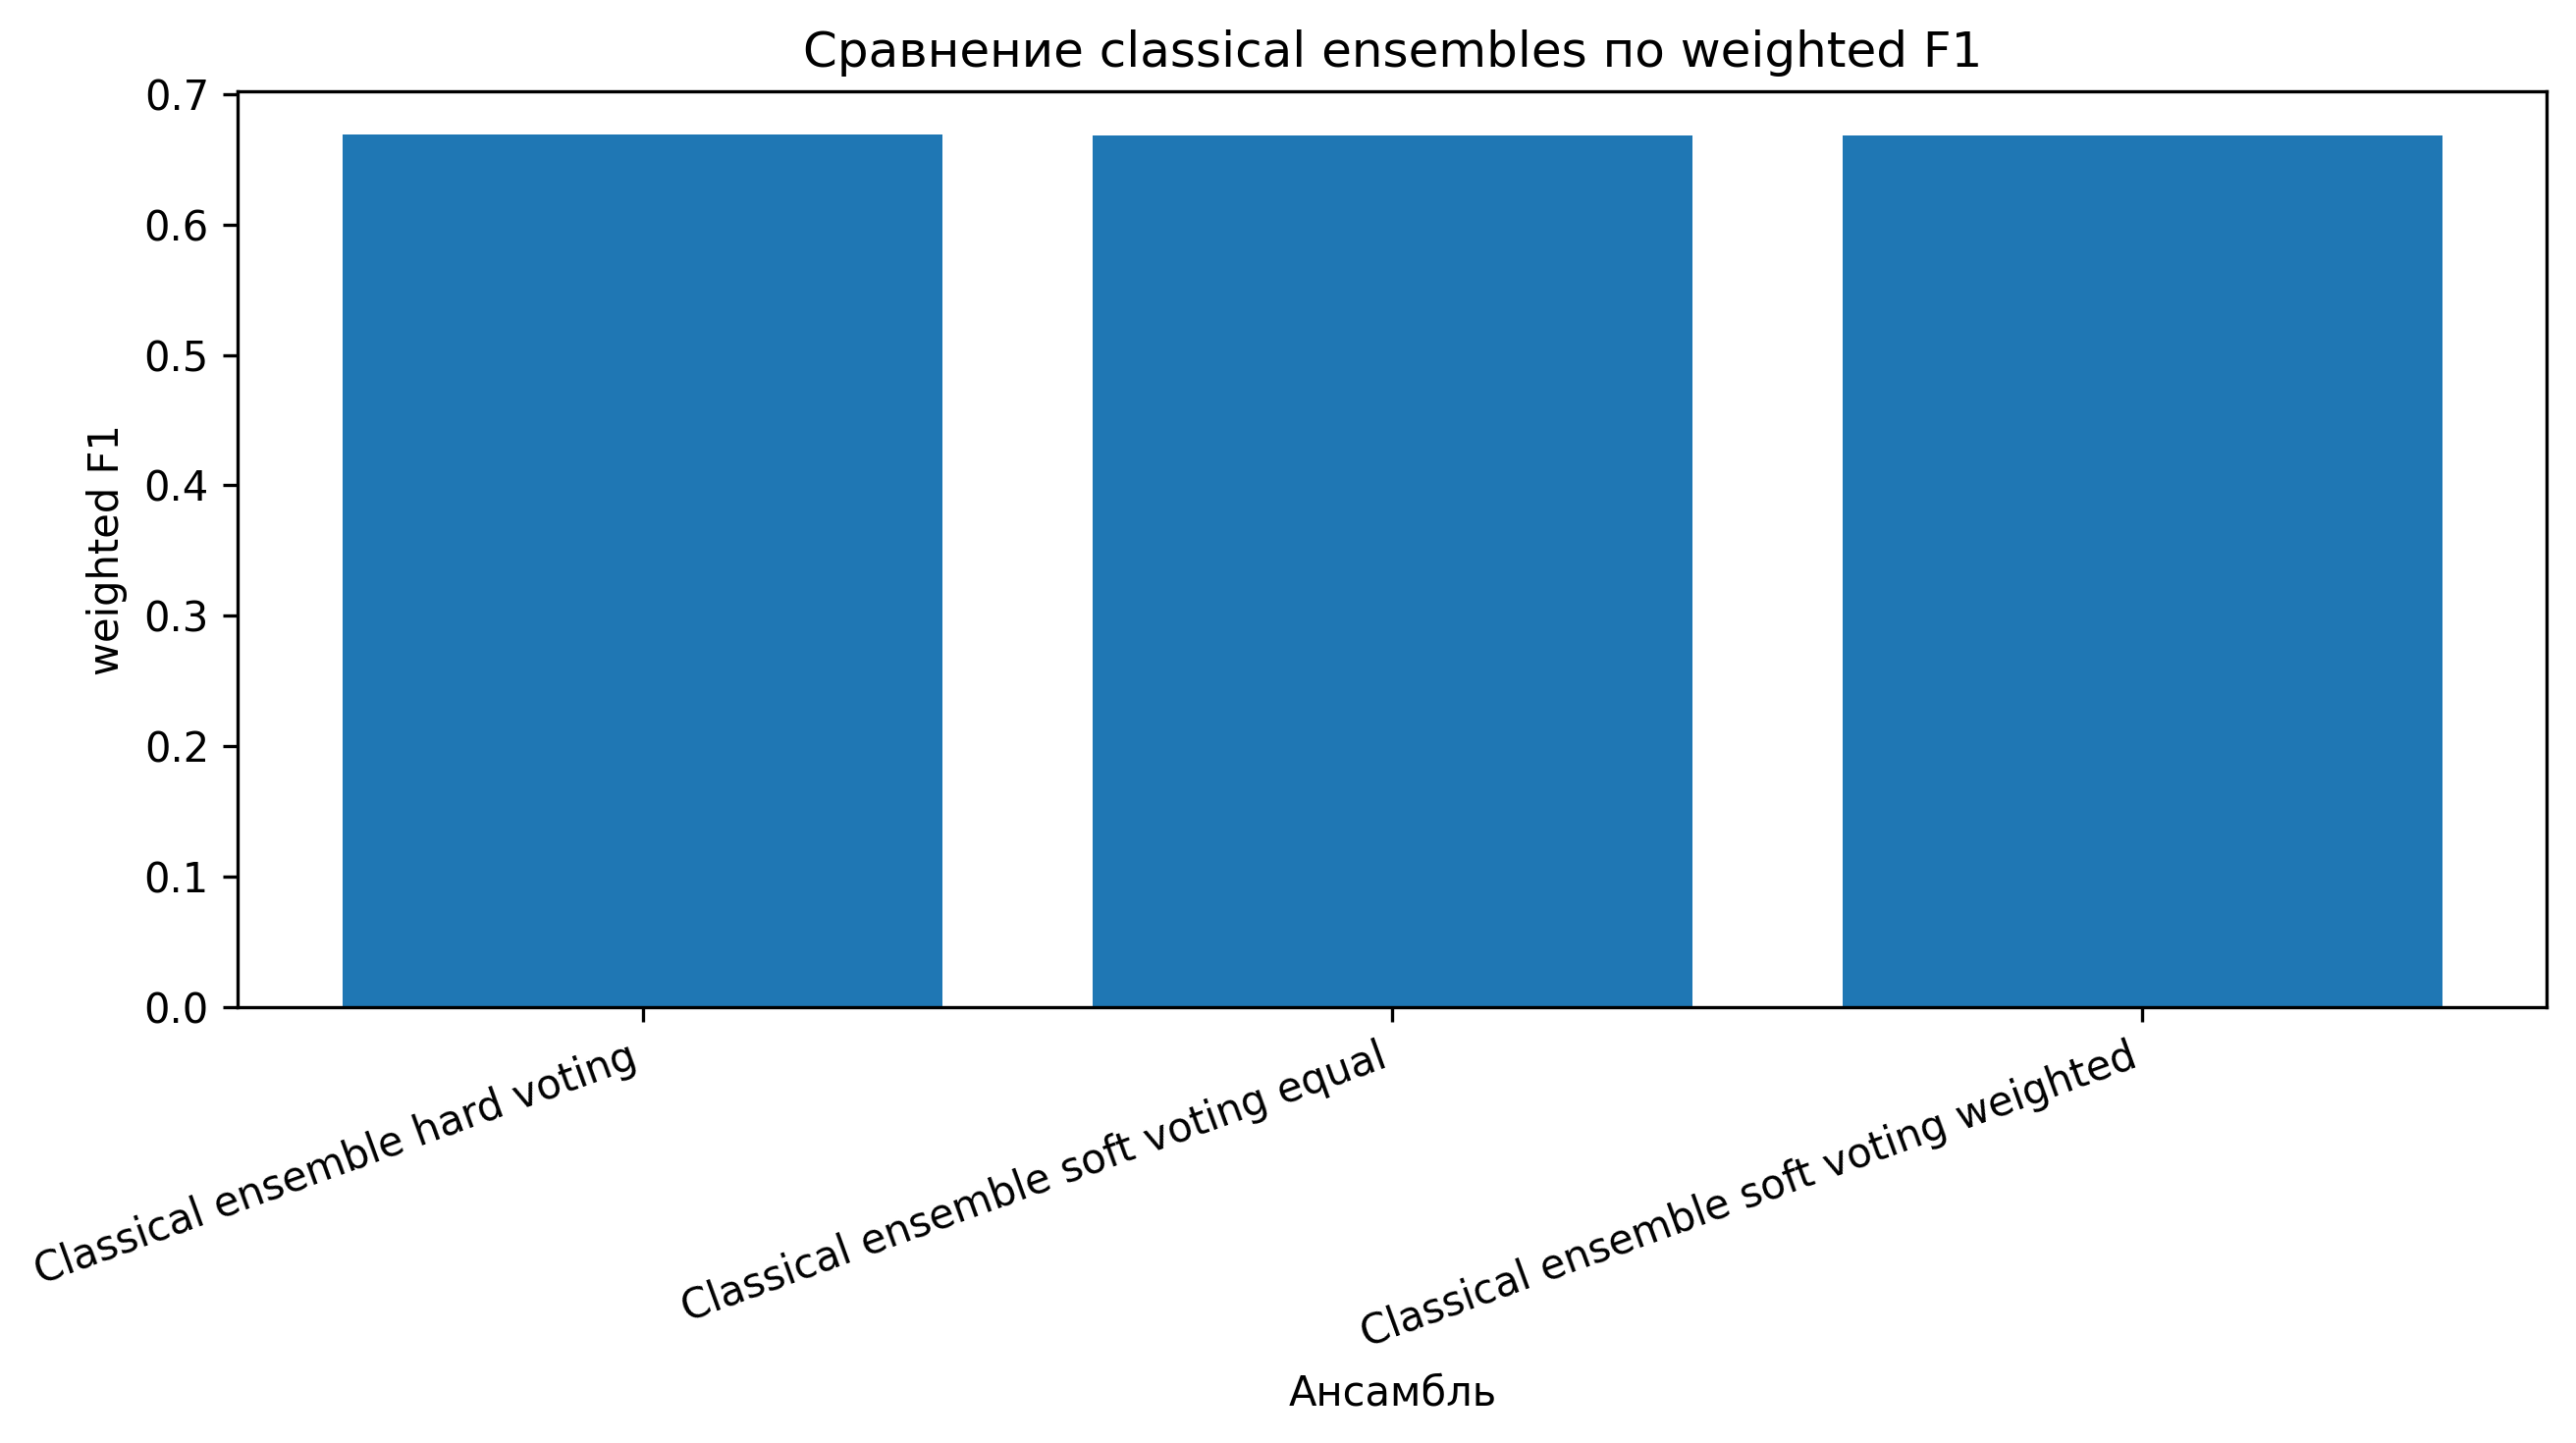

In [22]:
import matplotlib.pyplot as plt

plot_df = e5_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение classical ensembles по weighted F1")
plt.xlabel("Ансамбль")
plt.ylabel("weighted F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e5_ensemble_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

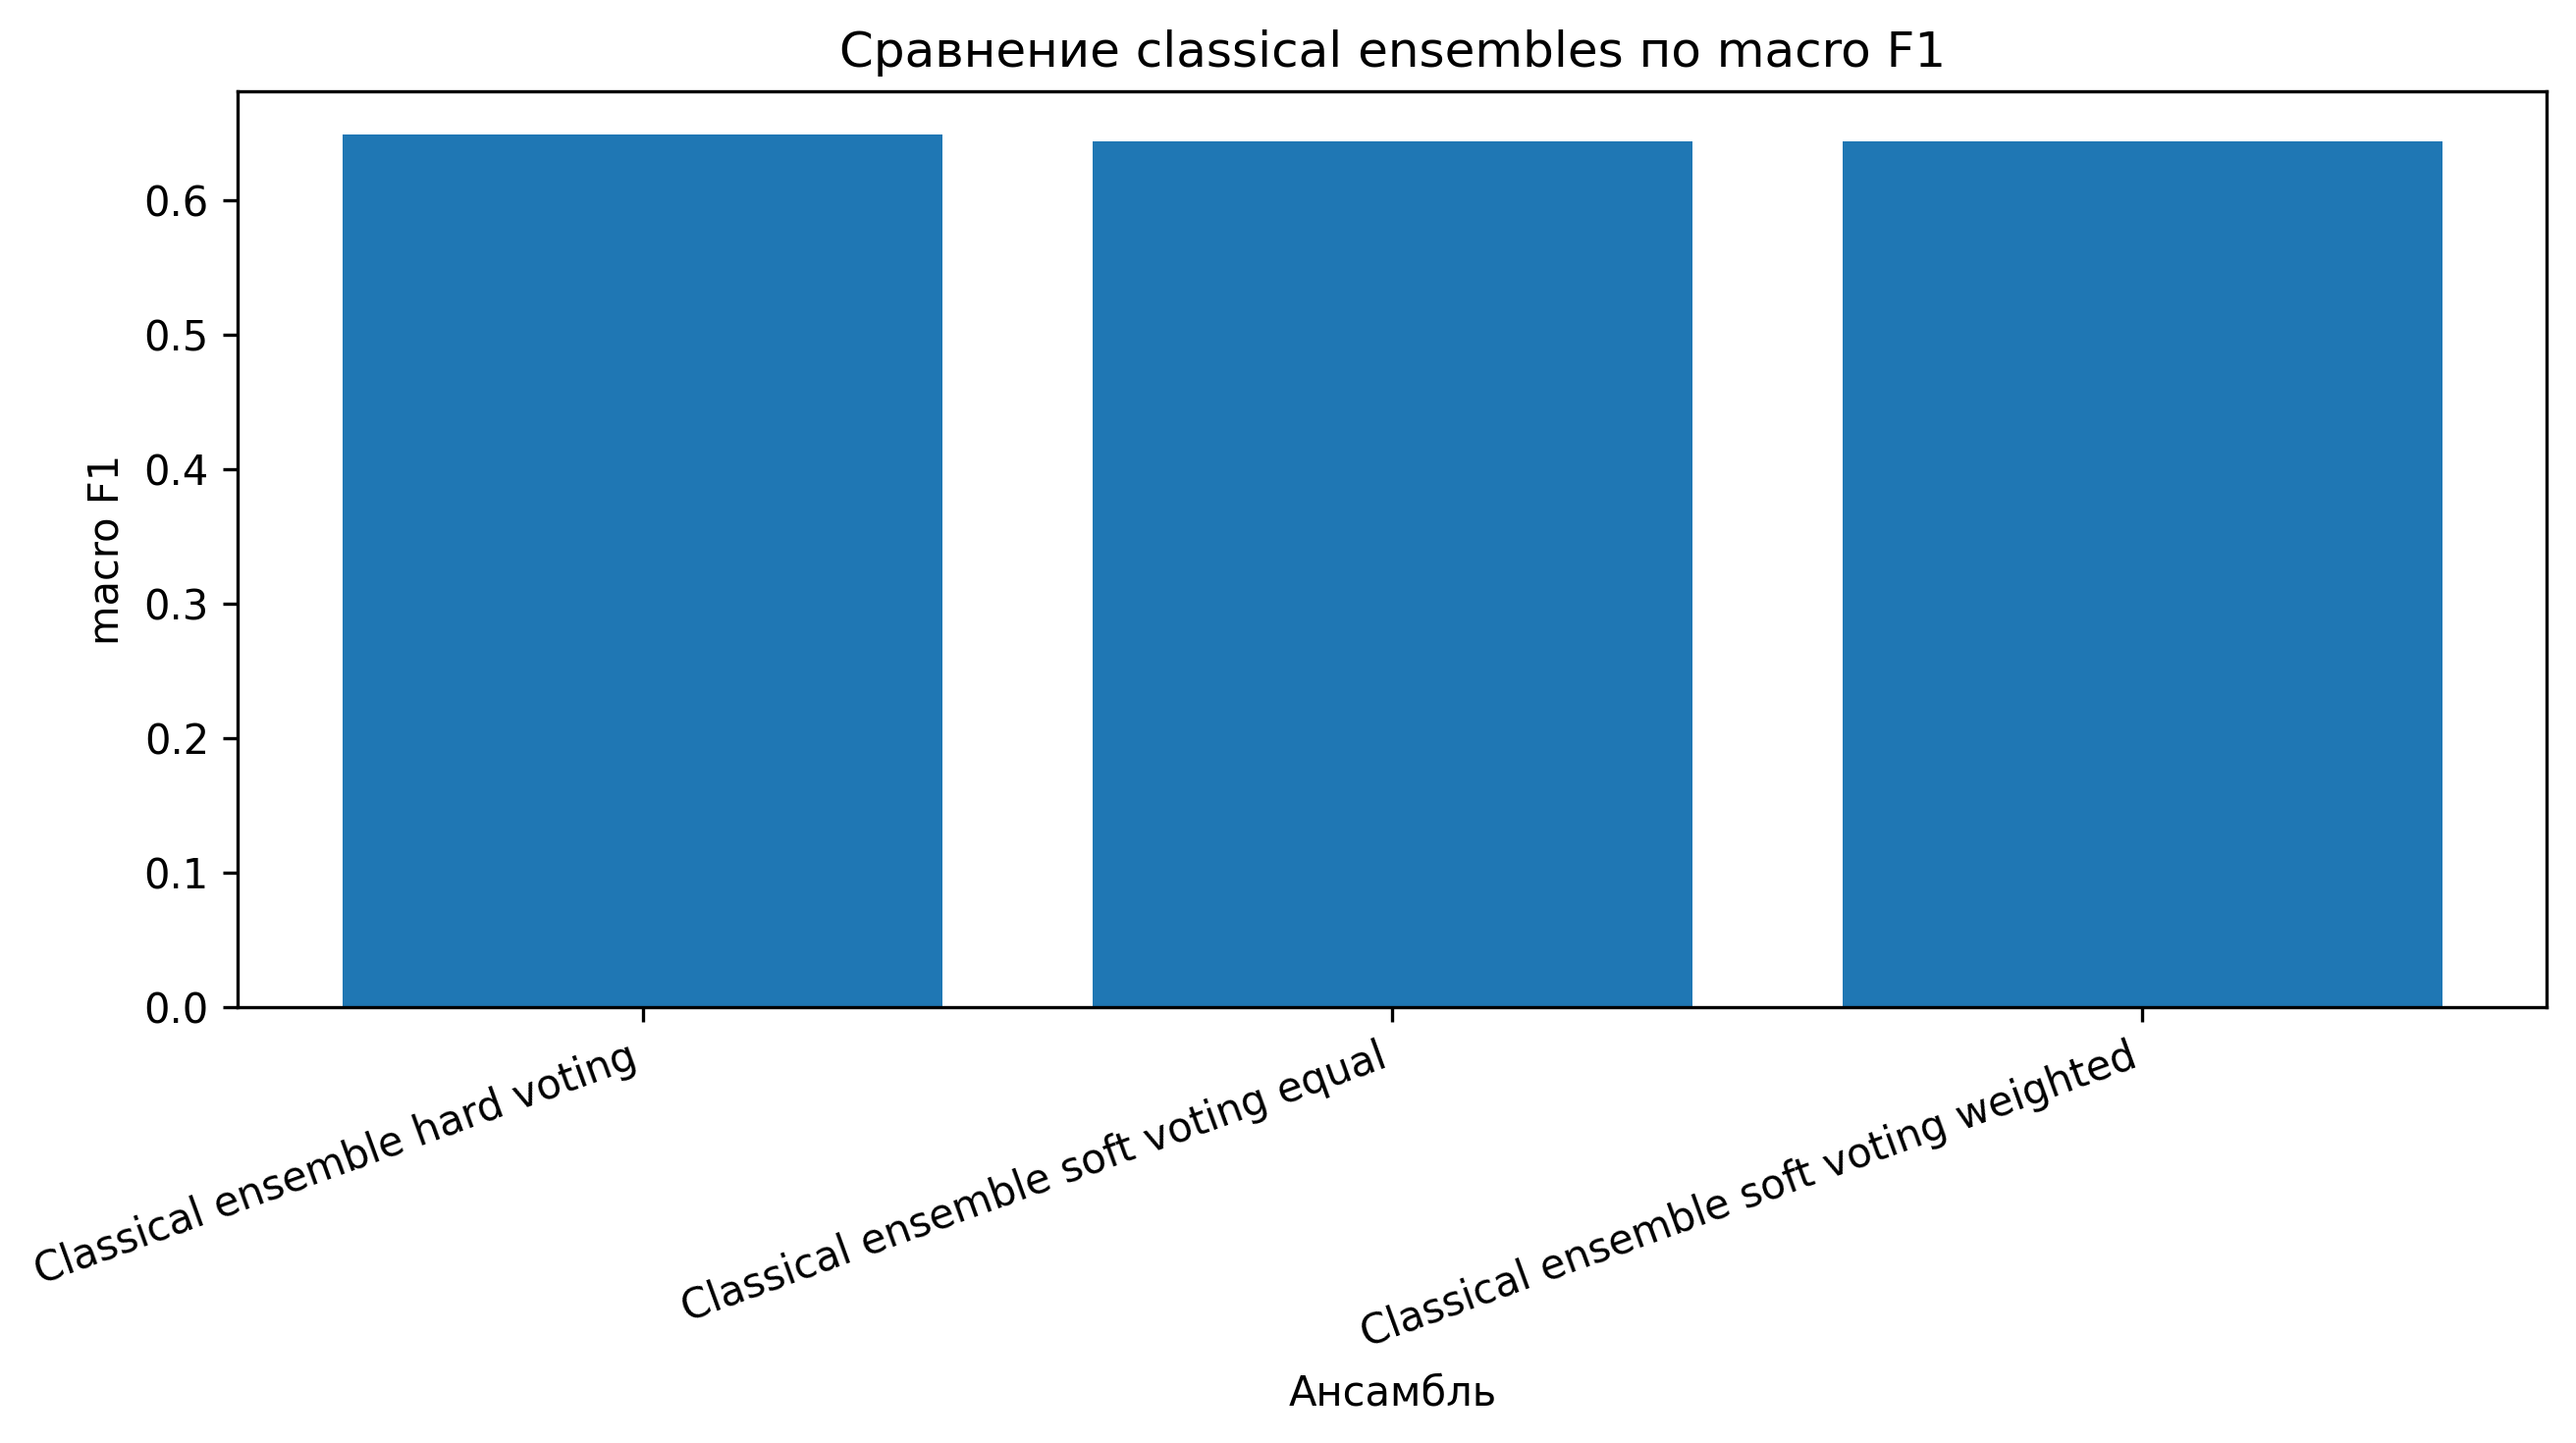

In [23]:
plot_df_macro = e5_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение classical ensembles по macro F1")
plt.xlabel("Ансамбль")
plt.ylabel("macro F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e5_ensemble_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
best_e5_model_name = e5_results_df.iloc[0]["model"]
print("Best E5 ensemble:", best_e5_model_name)

Best E5 ensemble: Classical ensemble hard voting


In [25]:
predictions_map = {
    "Classical ensemble hard voting": y_pred_hard,
    "Classical ensemble soft voting equal": y_pred_soft_equal,
    "Classical ensemble soft voting weighted": y_pred_soft_weighted
}

best_e5_pred = predictions_map[best_e5_model_name]

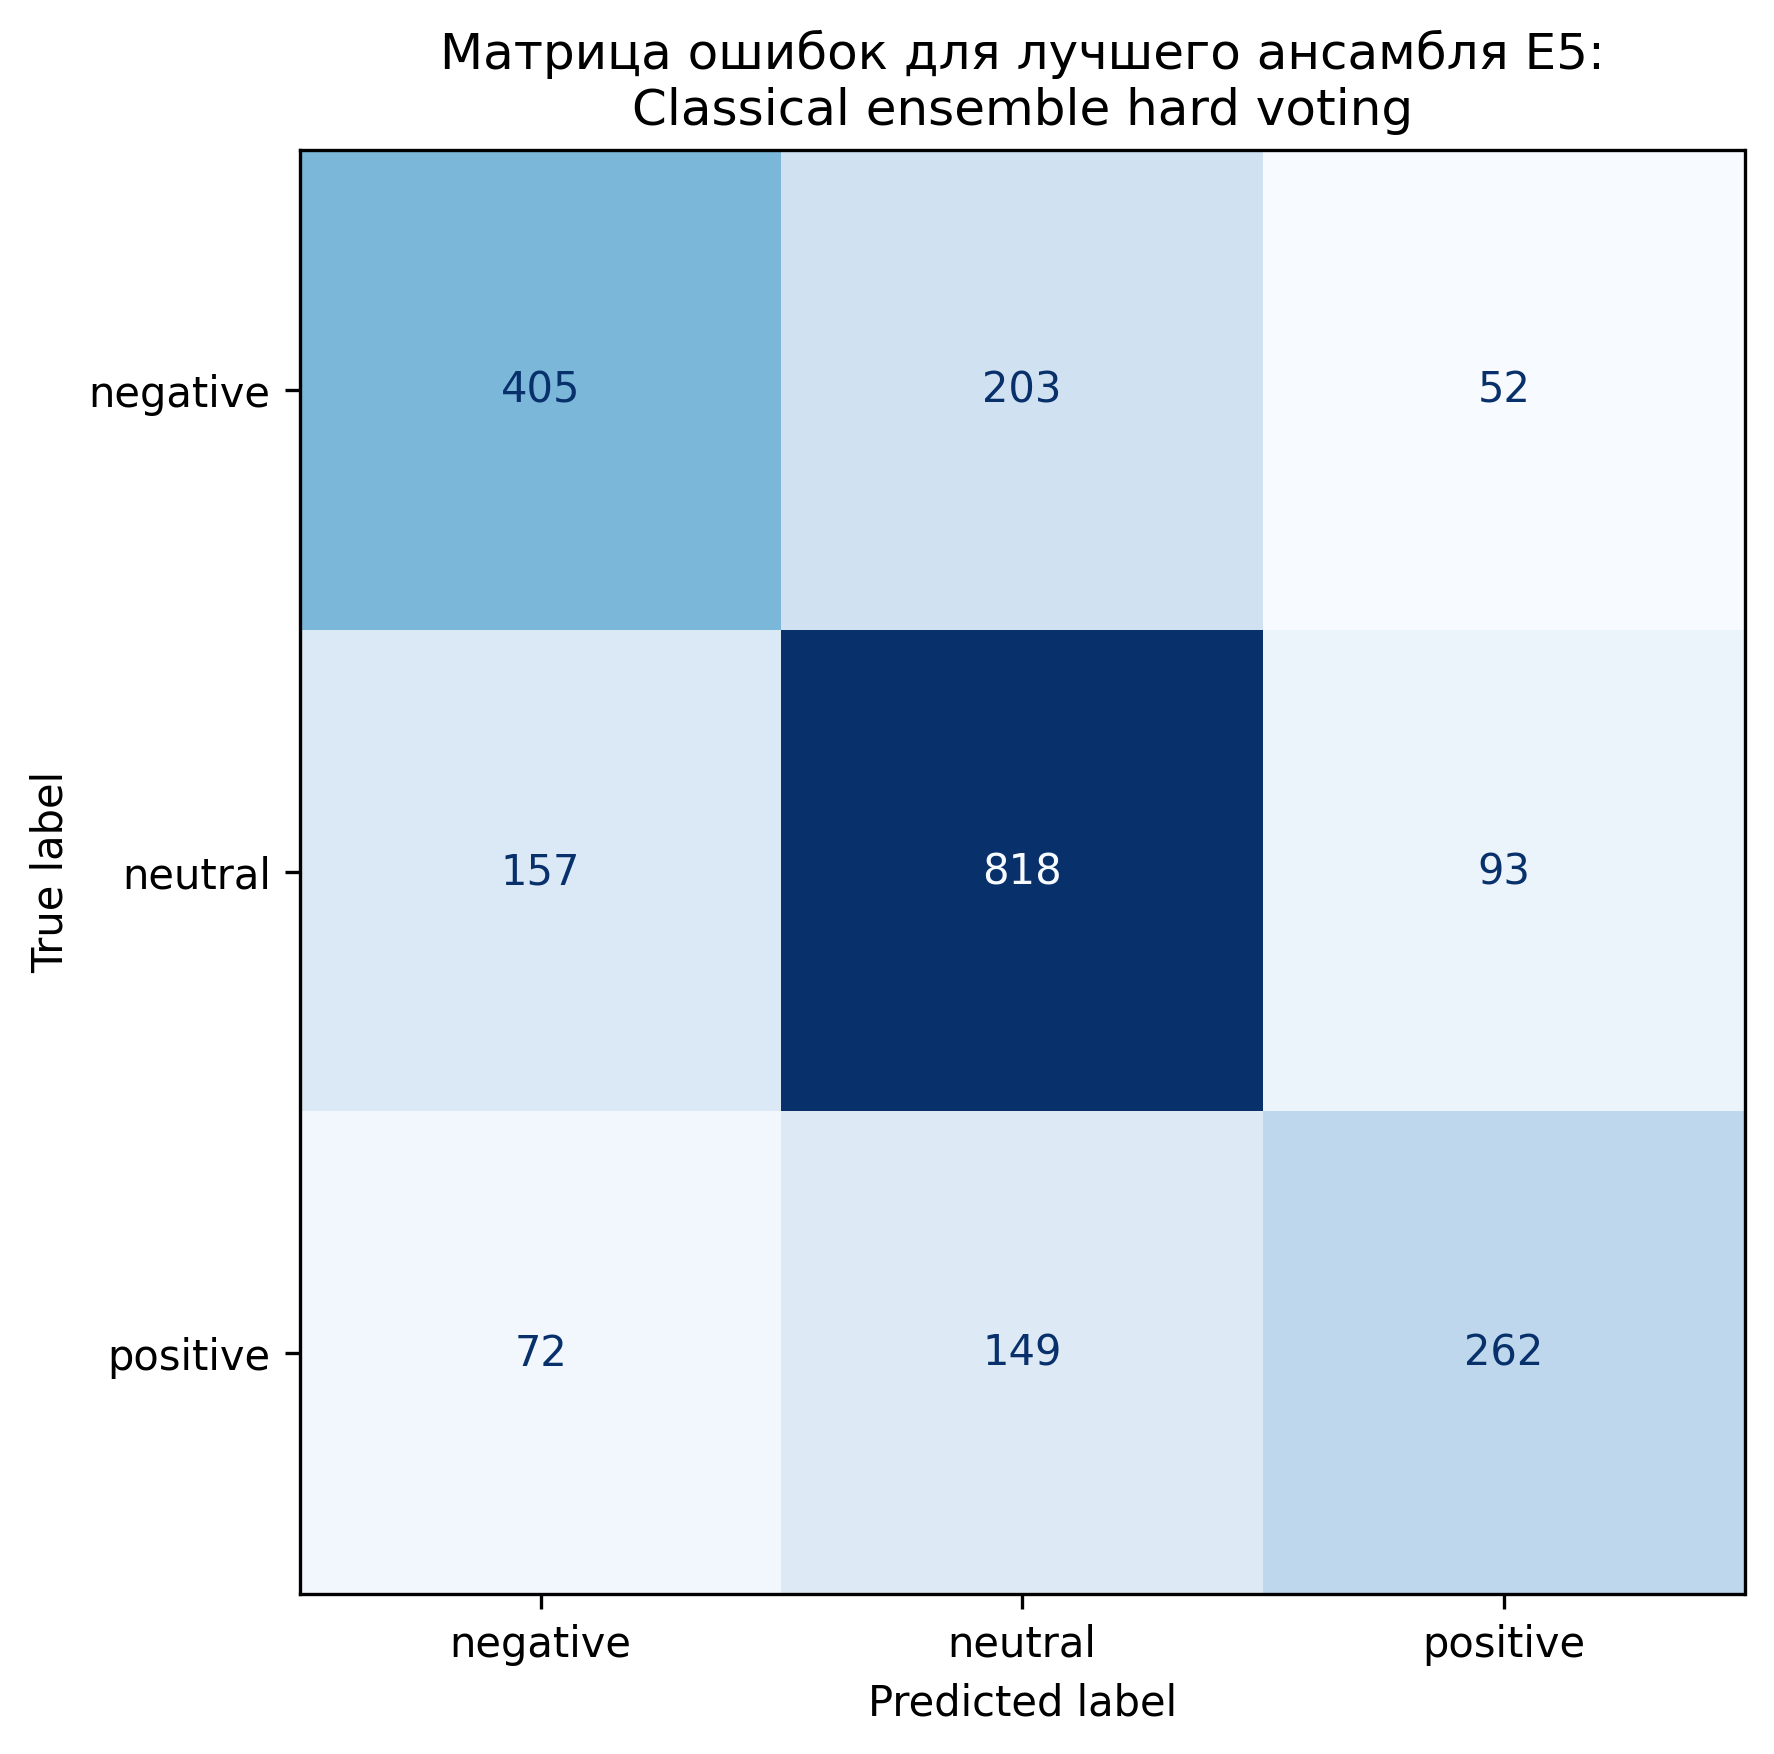

In [26]:
labels_order = ["negative", "neutral", "positive"]

cm_best_e5 = confusion_matrix(y_test, best_e5_pred, labels=labels_order)
disp_best_e5 = ConfusionMatrixDisplay(confusion_matrix=cm_best_e5, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_best_e5.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшего ансамбля E5:\n{best_e5_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "e5_best_ensemble_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
experiment_ids = [f"E5-{i+1}" for i in range(len(e5_results_df))]

e5_registry = e5_results_df.copy()
e5_registry.insert(0, "experiment_id", experiment_ids)
e5_registry["dataset"] = "RuSentiTweet"
e5_registry["train_split"] = "train_final"
e5_registry["test_split"] = "test_final"
e5_registry["status"] = "completed"

display(e5_registry)

,experiment_id,model,ensemble_type,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,dataset,train_split,test_split,status
0,E5-1,Classical ensemble hard voting,hard_voting,"char TF-IDF (3,5)",0.6716,0.6690,0.6716,0.6686,0.6486,3.4531,42,RuSentiTweet,train_final,test_final,completed
1,E5-2,Classical ensemble soft voting equal,soft_voting_equal,"char TF-IDF (3,5)",0.6771,0.6805,0.6771,0.6680,0.6440,7.4607,42,RuSentiTweet,train_final,test_final,completed
2,E5-3,Classical ensemble soft voting weighted,soft_voting_weighted,"char TF-IDF (3,5)",0.6771,0.6805,0.6771,0.6680,0.6440,7.4607,42,RuSentiTweet,train_final,test_final,completed


In [28]:
e5_registry.to_csv(TABLE_DIR / "e5_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e5_experiment_registry.csv")

Saved: e5_artifacts/tables/e5_experiment_registry.csv


In [29]:
BEST_STANDALONE_NAME = "SGDClassifier hinge + char TF-IDF (3,5)"
BEST_STANDALONE_WEIGHTED_F1 = 0.6741
BEST_STANDALONE_MACRO_F1 = 0.6517

best_ensemble_weighted_f1 = e5_results_df.iloc[0]["weighted_f1"]
best_ensemble_macro_f1 = e5_results_df.iloc[0]["macro_f1"]

delta_weighted = round(best_ensemble_weighted_f1 - BEST_STANDALONE_WEIGHTED_F1, 4)
delta_macro = round(best_ensemble_macro_f1 - BEST_STANDALONE_MACRO_F1, 4)

e5_summary = f"""
E5 CLASSICAL ENSEMBLE SUMMARY

Goal:
Evaluate whether ensembles of strong classical models improve performance
over the best standalone classical model.

Dataset:
RuSentiTweet

Train shape:
{train_df.shape}

Test shape:
{test_df.shape}

Representation:
char TF-IDF (3,5)

Base models:
- SGDClassifier hinge (default)
- RidgeClassifier (balanced)
- Linear SVM (balanced)

Ensemble methods:
- hard voting
- soft voting equal
- soft voting weighted

Best ensemble:
{e5_results_df.iloc[0]["model"]}

Best ensemble metrics:
accuracy = {e5_results_df.iloc[0]["accuracy"]}
weighted_f1 = {best_ensemble_weighted_f1}
macro_f1 = {best_ensemble_macro_f1}

Best standalone classical reference:
{BEST_STANDALONE_NAME}
weighted_f1 = {BEST_STANDALONE_WEIGHTED_F1}
macro_f1 = {BEST_STANDALONE_MACRO_F1}

Delta vs best standalone:
weighted_f1 delta = {delta_weighted}
macro_f1 delta = {delta_macro}

Full ranking:
{e5_results_df[["model", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e5_summary.txt", "w", encoding="utf-8") as f:
    f.write(e5_summary)

print("Saved:", LOG_DIR / "e5_summary.txt")

Saved: e5_artifacts/logs/e5_summary.txt
